# Supplementary Fig. 9 — expected and observed number of DCS variants

- **a** — **expected** number of DCS variants detectable above a given VAF, for individuals aged 55, 65, 75
  and 85, obtained by integrating the clone-size density (eq. 5) over the fitness distribution inferred
  across the top-10 clonal-haematopoiesis genes and then over VAF (main plot, log axis; inset zooms to the
  0.1-50 % range).
- **b** — **observed** number of DCS "variants" above a given VAF in the test hDNA sample (peripheral-blood
  DNA from a 65-year-old individual), showing far more low-VAF calls than expected - the motivation for the
  *in silico* noise correction (main plot + 0.1-50 % inset).

(The main plot and its inset are saved as separate panels and composited in the published figure.)

## Data availability

Panel **a** uses only the inferred fitness-distribution parameters (hard-coded, from the DFE across the
top-10 CH genes) and the panel size - no data files.

Panel **b** reads the two technical replicates of the hDNA test sample (`SEM11503A`, `SEM11503B`), which
are **not distributed with this code**: they report reference and variant read depth at every panel
position, which carries the germline genotypes of the 65-year-old individual whose peripheral-blood DNA
this is. (The Myeloid Reference Standard dilutions are the subject of Supplementary Fig. 8 and are not
used here.)

| path | contents | location |
|---|---|---|
| `Horizon_reference_standards/SEM11503{A,B}_*_all_positions.vcf` | DCS calls at all panel positions, per replicate (mean panel depth) | not distributed |
| `Horizon_reference_standards/SEM11503{A,B}_*_annotated.txt` | annotated DCS variant calls, per replicate | not distributed |

The sequencing data for the Myeloid Reference Standard dilutions and the hDNA sample is **not
deposited**: the EGA submission covers the UKCTOCS participant samples only. These panels therefore cannot
be re-run from public data, and the code is included for transparency. (The observed VAFs of the validated
reference-standard variants are published separately, as **Table S1** of the paper.)


In [1]:
# imported packages
import csv
import os

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import integrate


In [2]:
#colours (colorbrewer2)
blue3 = '#6baed6'
grey2 = '#cccccc'
grey3 = '#969696'
grey4 = '#636363'

#greyscale ramp used for the four age curves
gray1 = '#636363'
gray2 = '#969696'
gray3 = '#bdbdbd'
gray4 = '#d9d9d9'
grays = [gray1, gray2, gray3, gray4]


In [3]:
#only the hDNA test sample is used here
sample_names = ['SEM11503A', 'SEM11503B']

# DCS

## Read in data

### All positions

In [4]:
#Filenames for variants in each sample...
n = 0
sample_filenames_all_positions = {}

for sample in sample_names:
    filename = 'Data_files/Horizon_reference_standards/'+sample+'_SNV_SNV_watson_code_DCS_variants_MUFs_3_all_positions.vcf'
    if os.path.isfile(filename):
        sample_filenames_all_positions[sample]=filename
    n+=1

sample_filenames_all_positions

{'SEM11503A': 'Data_files/Horizon_reference_standards/SEM11503A_SNV_SNV_watson_code_DCS_variants_MUFs_3_all_positions.vcf',
 'SEM11503B': 'Data_files/Horizon_reference_standards/SEM11503B_SNV_SNV_watson_code_DCS_variants_MUFs_3_all_positions.vcf'}

In [5]:
def depth_across_sample(all_positions_file):
    depths_list = []

    with open(all_positions_file) as txtfile:
        reader = csv.reader(txtfile, delimiter = '\t')
        row_count = 0
        for row in reader:
            if row_count>32:
                total_depth = int(row[6].split(';')[2].split('=')[1])
                depths_list.append(total_depth)

            row_count+=1

        mean_depth = np.mean(depths_list)
        
    return mean_depth

In [6]:
samples_depths_across_panel={}

for sample, filename in sample_filenames_all_positions.items():
    mean_depth = depth_across_sample(filename)
    samples_depths_across_panel[sample]=mean_depth

samples_depths_across_panel

{'SEM11503A': np.float64(2080.3892421378246),
 'SEM11503B': np.float64(2404.006698038677)}

### Variants

In [7]:
#Filenames for variants in each sample...
n = 0
sample_filenames = {}

for sample in sample_names:
    filename = 'Data_files/Horizon_reference_standards/'+sample+'_SNV_SNV_watson_code_DCS_variants_MUFs_3_annotated.txt'
    if os.path.isfile(filename):
        sample_filenames[sample]=filename
    n+=1

sample_filenames

{'SEM11503A': 'Data_files/Horizon_reference_standards/SEM11503A_SNV_SNV_watson_code_DCS_variants_MUFs_3_annotated.txt',
 'SEM11503B': 'Data_files/Horizon_reference_standards/SEM11503B_SNV_SNV_watson_code_DCS_variants_MUFs_3_annotated.txt'}

In [8]:
def variants_list_and_dict(variants_file):
    variants_list = []
    variants_dict = {}

    with open(variants_file) as txtfile:
        reader = csv.reader(txtfile, delimiter = '\t')
        row_count = 0
        for row in reader:
            if row_count>0:
    #             print(row)
                REF = row[3]
                ALT = row[4]
                base_change = REF+'>'+ALT
                total_depth = int(row[5])
                VAF = float(row[7])
                variant_type = row[9] #e.g. SNV, Deletion, Insertion
                gene = row[10]
                AA_change = row[14]
                exonic_function = row[15]
                RSID = row[16]
                MAF_1000_genomes = row[17]
                if MAF_1000_genomes == '-':
                    MAF_1000_genomes = 0
                else:
                    MAF_1000_genomes = float(MAF_1000_genomes)
                variant_mean_UMI_family_size = float(row[23])
                mean_pos_read = float(row[24])
                mean_mapping_quality = float(row[26])
                strand_bias_phred = float(row[30])
                exac_all = row[31]
                if exac_all == '.':
                    exac_all = 0
                else:
                    exac_all = float(exac_all)
                    
                if strand_bias_phred<60:
                    if variant_mean_UMI_family_size>2:
                        if mean_pos_read >8:
#                             if variant_type == 'SNV':
                            if RSID == '-':
                                if exac_all <0.01:
                                    if total_depth >500:
                                        variants_list.append(gene+' '+AA_change)
                                        variants_dict[gene+' '+AA_change] = {'total_depth': total_depth, 'VAF': VAF, 'variant_type': variant_type, 'exonic_function':  exonic_function, 'RSID': RSID, 'MAF_1000_genomes': MAF_1000_genomes, 
                                                                             'variant_mean_UMI_family_size': variant_mean_UMI_family_size, 'mean_pos_read': mean_pos_read, 'mean_mapping_quality': mean_mapping_quality,
                                                                            'strand_bias_phred': strand_bias_phred, 'exac_all': exac_all, 'base_change': base_change}

            row_count+=1
    #         if row_count>10:
    #             break
    return variants_list, variants_dict

In [9]:
samples_variants_lists = {}
samples_variants_dicts = {}

for sample, filename in sample_filenames.items():
    variants_list, variants_dict = variants_list_and_dict(filename)
    samples_variants_lists[sample]=variants_list
    samples_variants_dicts[sample]=variants_dict

## Look at replicates

In [11]:
def replicates_dictionary(replicate_1, replicate_2, samples_variants_list, samples_variants_dict, samples_depths_across_panel):
    
    replicates_dict = {}
    replicates_base_change = {}
    
    list_of_all_variants = []
    rep1_variants = samples_variants_list[replicate_1]
    rep2_variants = samples_variants_list[replicate_2]
    
    for i in rep1_variants:
        list_of_all_variants.append(i)
    for i in rep2_variants:
        if i not in list_of_all_variants:
            list_of_all_variants.append(i)
            
    for variant in list_of_all_variants:
        replicates_dict[variant]=[]
        if variant in samples_variants_dict[replicate_1].keys():
            replicate_1_variant_details = samples_variants_dict[replicate_1][variant]
            r1_VAF = replicate_1_variant_details['VAF']
            replicates_dict[variant].append(r1_VAF)
            replicates_base_change[variant]=replicate_1_variant_details['base_change']
        else:
            replicates_dict[variant].append(0)
        if variant in samples_variants_dict[replicate_2].keys():
            replicate_2_variant_details = samples_variants_dict[replicate_2][variant]
            r2_VAF = replicate_2_variant_details['VAF']
            replicates_dict[variant].append(r2_VAF)
            replicates_base_change[variant]=replicate_2_variant_details['base_change']
        else:
            replicates_dict[variant].append(0)
            
    rep1_mean_depth = samples_depths_across_panel[replicate_1]
    rep2_mean_depth = samples_depths_across_panel[replicate_2]
    mean_depth = np.mean([rep1_mean_depth, rep2_mean_depth])
            
    return replicates_dict, replicates_base_change, mean_depth

In [12]:
SEM_reps, SEM_base_changes, SEM_mean_depth = replicates_dictionary('SEM11503A', 'SEM11503B', samples_variants_lists, samples_variants_dicts, samples_depths_across_panel)

# Observed number of variants

### In just 1 replicate

In [13]:
SEM_rep1_VAFs = []
for k, v in SEM_reps.items():
    if v[0]!=0:
        SEM_rep1_VAFs.append(np.log10(v[0]))

SEM_rep1_VAFs_sorted = sorted(SEM_rep1_VAFs)
len(SEM_rep1_VAFs_sorted)

3507

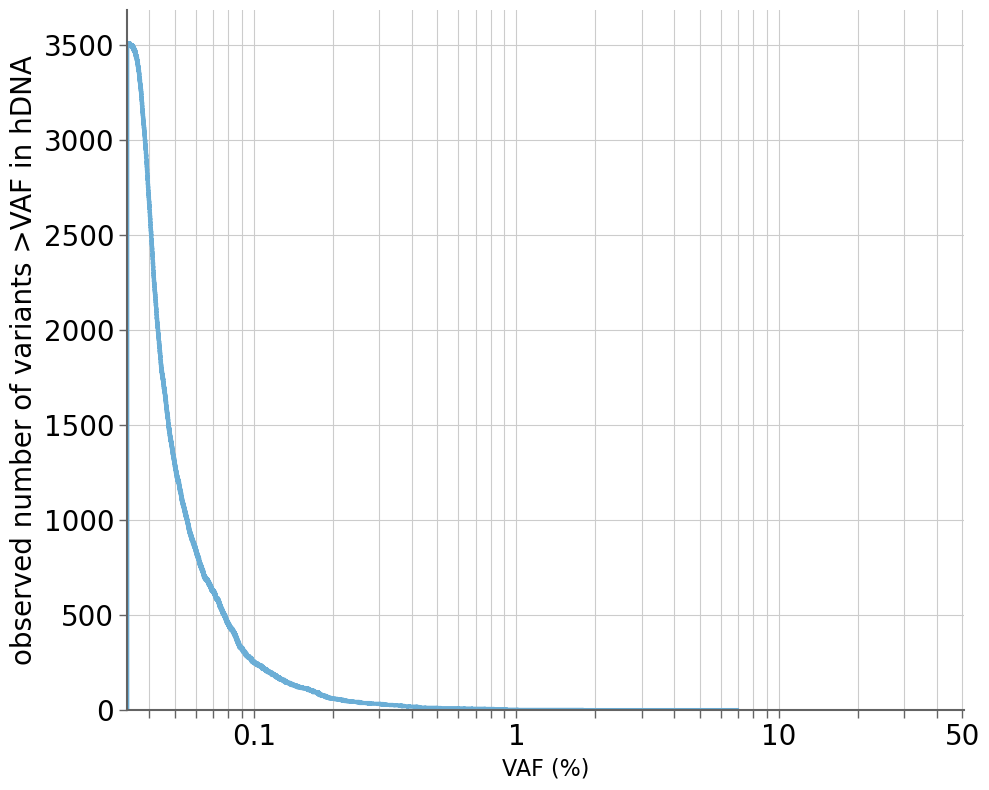

In [ ]:
#present in replicate 1
fig, ax1 = plt.subplots(1,1, figsize = (10, 8))

nbins = len(SEM_rep1_VAFs_sorted)

# plot the cumulative histogram
# n, bins, patches = ax1.hist(SEM_rep1_VAFs_sorted, nbins, density=True, histtype='step', cumulative=True, label='Empirical')

ax1.hist(SEM_rep1_VAFs_sorted, bins=nbins, histtype='step', cumulative=-1, lw = 3, color = blue3)

# ax1.set_xscale('log')

for ax in [ax1]:
#     ax.set_xscale('log')

    ax.set_xlabel('VAF (%)', fontsize = 16)
    ax.set_ylabel('observed number of variants >VAF in hDNA', fontsize = 20)
    ax.tick_params(axis = 'both', which = 'both', color = grey4, length = 6, width = 1, labelsize = 20)
    ax.tick_params(axis = 'both', which='minor', color = grey4, bottom=True, width = 1, length = 4)
    for axis in ['right', 'top']:
        ax.spines[axis].set_visible(False)
    for axis in ['bottom', 'left']:
        ax.spines[axis].set_linewidth(1.5)
        ax.spines[axis].set_color(grey4)

    x_major_ticks = [np.log10(0.0001), np.log10(0.0002), np.log10(0.0003), np.log10(0.0004), np.log10(0.0005), np.log10(0.0006), np.log10(0.0007), np.log10(0.0008), np.log10(0.0009),
                     np.log10(0.001), np.log10(0.002), np.log10(0.003), np.log10(0.004), np.log10(0.005), np.log10(0.006), np.log10(0.007), np.log10(0.008), np.log10(0.009), 
                     np.log10(0.01), np.log10(0.02), np.log10(0.03), np.log10(0.04), np.log10(0.05), np.log10(0.06), np.log10(0.07), np.log10(0.08), np.log10(0.09), 
                     np.log10(0.1), np.log10(0.2), np.log10(0.3), np.log10(0.4), np.log10(0.5)]
    x_major_tick_labels = ["0.01", "", "", "", "", "", "", "", "", 
                           "0.1", "", "", "", "", "", "", "", "", 
                           "1", "", "", "", "", "", "", "", "", 
                           "10", "", "", "","50"]
    ax.set_xticks(x_major_ticks)
    ax.set_xticklabels(x_major_tick_labels, fontsize = 20)
    
    ax.set_xlim(min(SEM_rep1_VAFs_sorted), np.log10(0.51))
    
    ax.grid(which = 'both', zorder = 0, color = grey2)

plt.tight_layout()
plt.show()

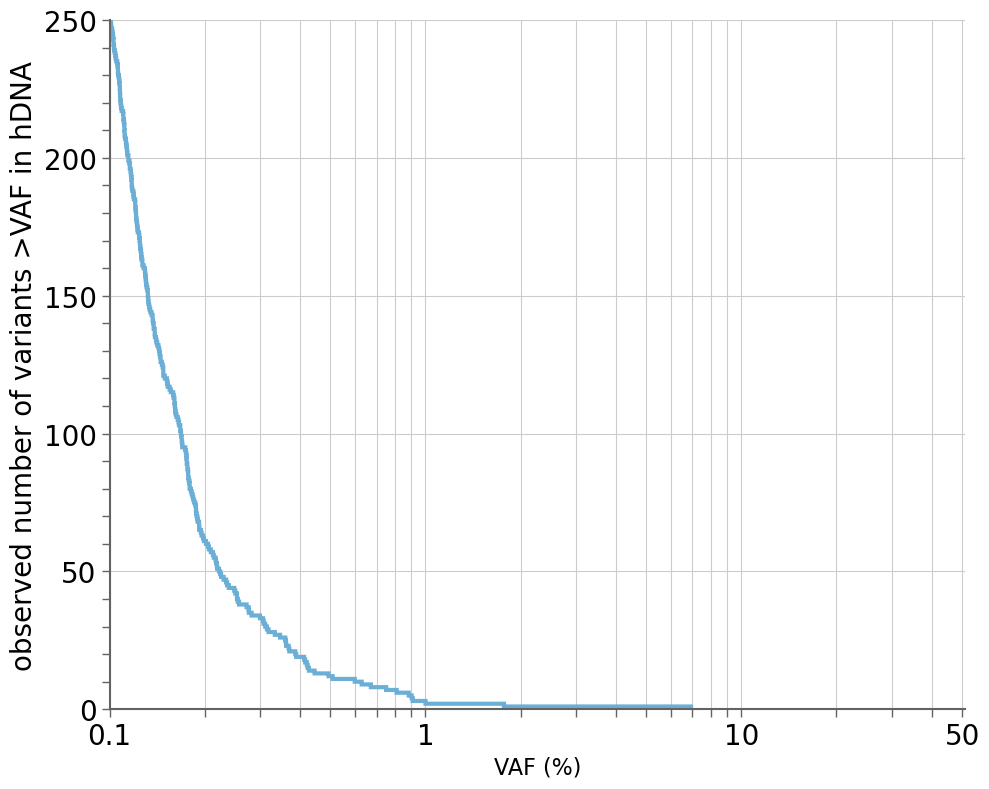

In [ ]:
#present in replicate 1
fig, ax1 = plt.subplots(1,1, figsize = (10, 8))

nbins = len(SEM_rep1_VAFs_sorted)

ax1.hist(SEM_rep1_VAFs_sorted, bins=nbins, histtype='step', cumulative=-1, lw = 3, color = blue3)


for ax in [ax1]:
    ax.set_xlabel('VAF (%)', fontsize = 16)
    ax.set_ylabel('observed number of variants >VAF in hDNA', fontsize = 20)
    ax.tick_params(axis = 'both', which = 'both', color = grey4, length = 6, width = 1, labelsize = 20)
    ax.tick_params(axis = 'x', which='minor', color = grey4, left=False, width = 1, length = 4)
    for axis in ['right', 'top']:
        ax.spines[axis].set_visible(False)
    for axis in ['bottom', 'left']:
        ax.spines[axis].set_linewidth(1.5)
        ax.spines[axis].set_color(grey4)

    x_major_ticks = [np.log10(0.0001), np.log10(0.0002), np.log10(0.0003), np.log10(0.0004), np.log10(0.0005), np.log10(0.0006), np.log10(0.0007), np.log10(0.0008), np.log10(0.0009),
                     np.log10(0.001), np.log10(0.002), np.log10(0.003), np.log10(0.004), np.log10(0.005), np.log10(0.006), np.log10(0.007), np.log10(0.008), np.log10(0.009), 
                     np.log10(0.01), np.log10(0.02), np.log10(0.03), np.log10(0.04), np.log10(0.05), np.log10(0.06), np.log10(0.07), np.log10(0.08), np.log10(0.09), 
                     np.log10(0.1), np.log10(0.2), np.log10(0.3), np.log10(0.4), np.log10(0.5)]
    x_major_tick_labels = ["0.01", "", "", "", "", "", "", "", "", 
                           "0.1", "", "", "", "", "", "", "", "", 
                           "1", "", "", "", "", "", "", "", "", 
                           "10", "", "", "","50"]
    ax.set_xticks(x_major_ticks)
    ax.set_xticklabels(x_major_tick_labels, fontsize = 20)
    
    ax.set_xlim(np.log10(0.001), np.log10(0.51))
    ax.set_ylim(0, 250)
    
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(10))

    ax.grid(which = 'major', zorder = 0, color = grey2)

plt.tight_layout()
plt.show()


# Expected number of variants

In [16]:
#From distribution across top 10 most mutated myeloid genes
b = 3.27535774e-01
d = 3.01655956e-04
s_max = 1.61181839e-01
N = 9.40166610e+04

s_peak = 0.0
s_range=np.linspace(0.0, s_max, 10000000)
    
weights=np.array([np.exp(-(abs(s-s_peak)/d)**b)*(s_max/(len(s_range)-1)) for s in s_range])
normalization=np.sum(weights)

normalization

np.float64(0.001902918604288032)

In [17]:
def mu_of_s(b, d, s, u): 
    return (u/normalization)*np.exp(-((abs(s))/d)**b)

def density_of_clones(f, s, t, u, N):
    #the integrand is singular at f = 0 and f = 0.5; quad evaluates near those endpoints,
    #so the resulting inf/nan are expected and do not affect the quadrature
    with np.errstate(divide='ignore', invalid='ignore'):
        return ((2*N*u)/(f*(1-2*f)))*np.exp(-f/((1-2*f)*((np.exp(s*t)-1)/(2*N*s))))

def density_averaged_over_s(f, t, b, d, s_max, u, N):
    return integrate.quad(lambda s: density_of_clones(f, s, t, mu_of_s(b, d, s, u), N), 0.0001, s_max)[0]

def prevalence(fmin, fmax, t, b, d, s_max, u, N):
    expected_number_clones =integrate.quad(lambda f: density_averaged_over_s(f, t, b, d, s_max, u, N), fmin, fmax)[0]
#     1.0-np.exp(-expected_number_clones)
    
    return expected_number_clones  #1-e^(-X): this is how many non-zeros there are in a Poisson distribution with mean of X

In [18]:
u = (2.7e-9)*58000
lower_VAF = 0.1
upper_VAF = 50
prevalence(lower_VAF/100, upper_VAF/100, 65, b, d, s_max, u, N)

8.041151984867087

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_47080/2035224964.py:11: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return integrate.quad(lambda s: density_of_clones(f, s, t, mu_of_s(b, d, s, u), N), 0.0001, s_max)[0]
/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_47080/2035224964.py:14: IntegrationWarning: Extremely bad integrand behavior occurs at some points of the
  integration interval.
  expected_number_clones =integrate.quad(lambda f: density_averaged_over_s(f, t, b, d, s_max, u, N), fmin, fmax)[0]


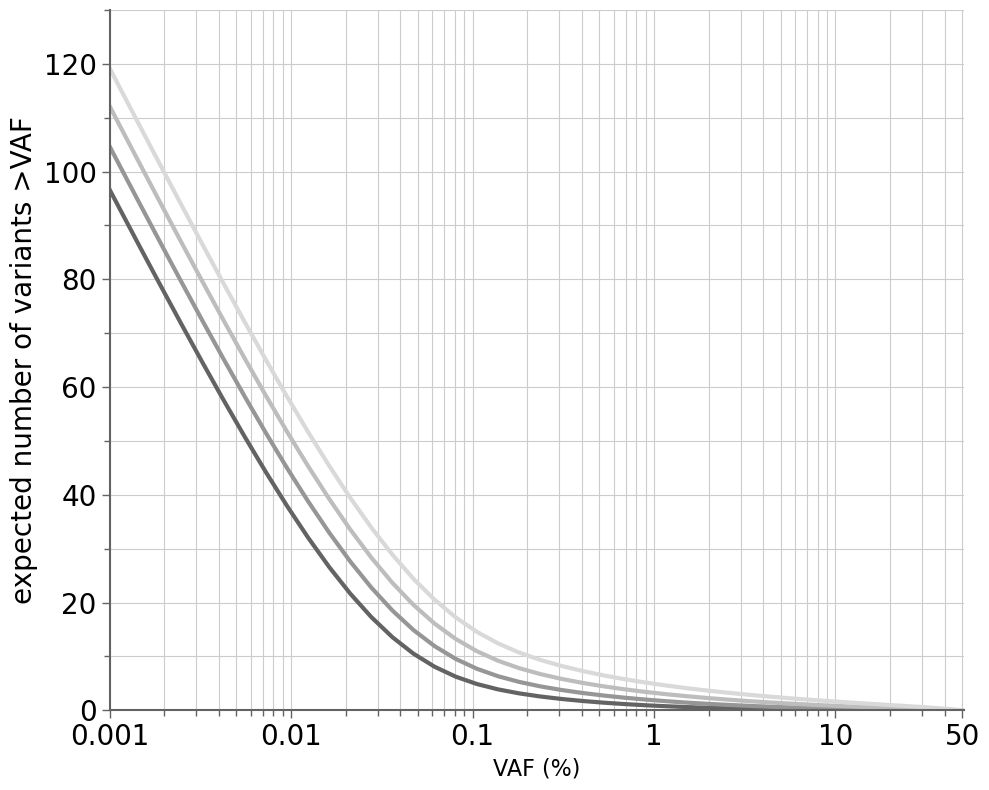

In [19]:
#Plot the expected number of variants

age = 65

fig, ax1 = plt.subplots(1,1, figsize = (10, 8))
lower_x = np.array([v for v in np.logspace(-6, np.log10(0.5), 50)]) #up to 0.5

n = 0
for age in np.linspace(55, 85, 4):
    cum_y=[prevalence(v, 0.5, age, b, d, s_max, u, N) for v in lower_x]

    y = []
    for i in cum_y:
        if np.isnan(i):
            y.append(0)
        else:
            y.append(i)

    ax1.plot(lower_x, y, lw = 3, color = grays[n])
    n+=1

ax1.set_ylim(0, 130)

for ax in [ax1]:
    ax.set_xlim(1e-5, 0.51)
    ax.set_xscale('log')

    ax.set_xlabel('VAF (%)', fontsize = 16)
    ax.set_ylabel('expected number of variants >VAF', fontsize = 20)
    ax.tick_params(axis = 'both', which = 'both', color = grey4, length = 6, width = 1, labelsize = 20)
    ax.tick_params(axis = 'both', which='minor', color = grey4, bottom=True, width = 1, length = 4)
    for axis in ['right', 'top']:
        ax.spines[axis].set_visible(False)
    for axis in ['bottom', 'left']:
        ax.spines[axis].set_linewidth(1.5)
        ax.spines[axis].set_color(grey4)

    x_major_ticks = [1e-5, 10**(-4), 10**(-3), 10**(-2), 10**(-1), 0.5]
    x_major_tick_labels = ["0.001", "0.01", "0.1", "1", "10", "50"]
    ax.set_xticks(x_major_ticks)
    ax.set_xticklabels(x_major_tick_labels, fontsize = 20)
    
    ax.yaxis.set_major_locator(ticker.MultipleLocator(20))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(10))

    ax.grid(which = 'both', zorder = 0, color = grey2)
    
plt.tight_layout()
plt.show()

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_45659/2035224964.py:11: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return integrate.quad(lambda s: density_of_clones(f, s, t, mu_of_s(b, d, s, u), N), 0.0001, s_max)[0]
/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_45659/2035224964.py:14: IntegrationWarning: Extremely bad integrand behavior occurs at some points of the
  integration interval.
  expected_number_clones =integrate.quad(lambda f: density_averaged_over_s(f, t, b, d, s_max, u, N), fmin, fmax)[0]


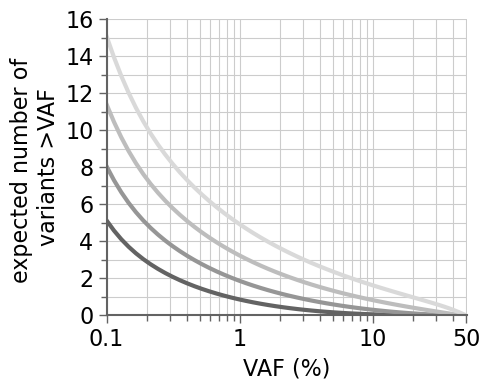

In [21]:
#Plot the expected number of variants

age = 65

fig, ax1 = plt.subplots(1,1, figsize = (5, 4))

lower_x = np.array([v for v in np.logspace(-3, np.log10(0.5), 50)]) #up to 0.5

n=0
for age in np.linspace(55, 85, 4):
    cum_y=[prevalence(v, 0.5, age, b, d, s_max, u, N) for v in lower_x]

    y = []
    for i in cum_y:
        if np.isnan(i):
            y.append(0)
        else:
            y.append(i)

    ax1.plot(lower_x, y, lw = 3, color = grays[n])
    n+=1
    
ax1.set_ylim(0, 16)

for ax in [ax1]:
    ax.set_xlim(1e-2, 0.51)
    ax.set_xscale('log')

    ax.set_xlabel('VAF (%)', fontsize = 16)
    ax.set_ylabel('expected number of \nvariants >VAF', fontsize = 16)
    ax.tick_params(axis = 'both', which = 'both', color = grey4, length = 6, width = 1, labelsize = 16)
    ax.tick_params(axis = 'both', which='minor', color = grey4, bottom=True, width = 1, length = 4)
    for axis in ['right', 'top']:
        ax.spines[axis].set_visible(False)
    for axis in ['bottom', 'left']:
        ax.spines[axis].set_linewidth(1.5)
        ax.spines[axis].set_color(grey4)

    x_major_ticks = [10**(-3), 10**(-2), 10**(-1), 0.5]
    x_major_tick_labels = ["0.1", "1", "10", "50"]
    ax.set_xticks(x_major_ticks)
    ax.set_xticklabels(x_major_tick_labels, fontsize = 16)
    
    ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(1))

    ax.grid(which = 'both', zorder = 0, color = grey2)
    
plt.tight_layout()
    
    
plt.show()